# TF-IDF + Logistic Regression

У цьому ноутбуці реалізовано повний baseline-пайплайн для задачі бінарної класифікації спаму:
- завантаження та перевірка даних;
- мінімальна підготовка тексту;
- train/test split;
- baseline-моделі;
- `Pipeline(TfidfVectorizer + LogisticRegression)`;
- підбір гіперпараметрів через `RandomizedSearchCV`;
- оцінка якості на test-вибірці;
- аналіз найважливіших ознак;
- збереження фінальної моделі.


## 1. Імпорт бібліотек

In [7]:
import os
import re
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [10]:
os.chdir("..") # ноутбук запускається з директорії models, то ми переходимо на рівень вище в корінь проєкту

In [11]:
os.getcwd() # поточна робоча директорія

'C:\\Users\\Hyperion\\PycharmProjects\\SpamFilteringSystem'

## 2. Конфігурація

In [12]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

DATA_PATH = Path("data/spam.csv")
TEXT_COL = "text"
TARGET_COL = "spam"

MODEL_DIR = Path("artifacts")
MODEL_DIR.mkdir(exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 3. Завантаження та базова перевірка даних

In [28]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
display(df.head())

required_columns = {TEXT_COL, TARGET_COL}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"У датасеті відсутні обов'язкові колонки: {missing_columns}")

df = df[[TEXT_COL, TARGET_COL]].copy()
df.rename(columns={TEXT_COL: "text", TARGET_COL: "label"}, inplace=True)

Shape: (91386, 2)


,text,spam
0,"__USER__ Це лека, і вона дуже крута, вона наша...",0
1,"У другому турі підтримав Віктора Ющенка, поста...",0
2,🪖 Твоя ідеальна підробітка? Знайдена. Без босі...,1
3,🔹 ВАКАНСІЯ | АДМІНІСТРАТОР у центрі протезуван...,1
4,__USER__ Відміть мене коли зможеш,0


In [30]:
# Базова валідація
print("\nТипи даних:")
df.dtypes


Типи даних:


text       str
label    int64
dtype: object

In [31]:
print("\nПропуски:")
df.isna().sum()


Пропуски:


text     0
label    0
dtype: int64

In [32]:
print("\nУнікальні значення target:")
df["label"].value_counts(dropna=False)


Унікальні значення target:


label
0    65165
1    26221
Name: count, dtype: int64

## 4. Мінімальна підготовка тексту

На цьому етапі:
- прибираємо зайві пробіли;
- переводимо нестрокові значення у рядки;
- видаляємо порожні записи.

Пунктуацію, спецсимволи та стоп-слова навмисно не видаляємо в основному пайплайні: вони можуть бути інформативними для задачі виявлення спаму.

In [14]:
def normalize_whitespace(text: str) -> str:
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(normalize_whitespace)
df = df[df["text"].str.len() > 0].copy()

# Переконуємося, що target бінарний
unique_labels = sorted(df["label"].dropna().unique().tolist())
if set(unique_labels) - {0, 1}:
    raise ValueError(f"Очікувались мітки 0/1, але знайдено: {unique_labels}")

print(f"Shape after cleanup: {df.shape}")
display(df.sample(min(5, len(df)), random_state=RANDOM_STATE))

Shape after cleanup: (91386, 2)


,text,label
77084,🔥 Хочеш ρеально зарοбляти? Βід 7000 гρн на тиж...,1
79427,Актуал - ФАВБЕТ🇺🇦 - КАЗІНОЮЕЙ🇺🇦 ❗️ВІК:21+❗️ ЦІ...,1
32273,__USER__ Хуй його знає,0
18425,Шyкаємo чат-мeнeджepiв з ПК!Якщo вu вмiєтe гpа...,1
3431,Мені цікаво коли вчителі говорять що видалять ...,0


## 5. Контрольна перевірка перед моделюванням

In [34]:
print("Дублікати повних рядків:", df.duplicated().sum())
print("Дублікати текстів:", df["text"].duplicated().sum())

class_dist = df["label"].value_counts(normalize=True).sort_index()
class_dist.rename("share")

Дублікати повних рядків: 0
Дублікати текстів: 0


label
0    0.713074
1    0.286926
Name: share, dtype: float64

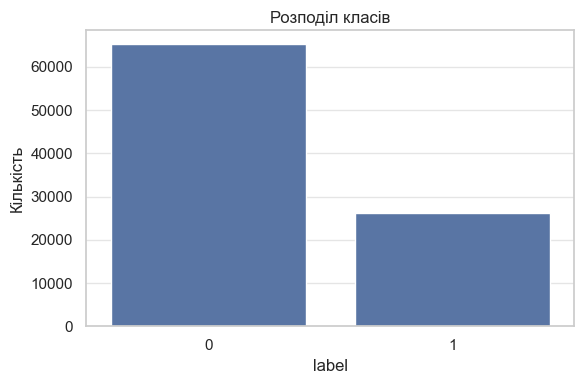

In [35]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="label")
ax.set_title("Розподіл класів")
ax.set_xlabel("label")
ax.set_ylabel("Кількість")
plt.tight_layout()
plt.show()

## 6. Train/Test split

Використовуємо стратифіковане розбиття, щоб зберегти співвідношення класів.

In [36]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 73108
Test size: 18278


In [38]:
print("\nTrain class distribution:")
y_train.value_counts(normalize=True).sort_index()


Train class distribution:


label
0    0.713068
1    0.286932
Name: proportion, dtype: float64

In [39]:
print("\nTest class distribution:")
y_test.value_counts(normalize=True).sort_index()


Test class distribution:


label
0    0.713098
1    0.286902
Name: proportion, dtype: float64

## 7. Допоміжні функції для оцінки моделей

In [17]:
def evaluate_predictions(y_true, y_pred, y_proba=None, model_name="model"):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
    else:
        metrics["roc_auc"] = np.nan
    return metrics


def plot_conf_matrix(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["ham", "spam"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 8. Простий baseline

Для коректного порівняння корисно мати стандартний `DummyClassifier`.

In [40]:
baseline_results = []

dummy_most_frequent = DummyClassifier(strategy="most_frequent")
dummy_most_frequent.fit(X_train.to_frame(), y_train)
dummy_pred = dummy_most_frequent.predict(X_test.to_frame())
baseline_results.append(
    evaluate_predictions(y_test, dummy_pred, model_name="Dummy most_frequent")
)

dummy_stratified = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy_stratified.fit(X_train.to_frame(), y_train)
dummy_pred = dummy_stratified.predict(X_test.to_frame())
dummy_proba = dummy_stratified.predict_proba(X_test.to_frame())[:, 1]
baseline_results.append(
    evaluate_predictions(y_test, dummy_pred, y_proba=dummy_proba, model_name="Dummy stratified")
)

baseline_df = pd.DataFrame(baseline_results).sort_values("f1", ascending=False)
baseline_df

,model,accuracy,precision,recall,f1,roc_auc
1,Dummy stratified,0.584856,0.274007,0.270976,0.272483,0.491058
0,Dummy most_frequent,0.713098,0.000000,0.000000,0.000000,NaN


## 9. Основний пайплайн: TF-IDF + Logistic Regression

Тут використовується `Pipeline`, щоб:
- уникнути leakage;
- зручно підбирати параметри;
- зберігати весь пайплайн як єдиний артефакт.

In [19]:
pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents=None,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=2000,
            ),
        ),
    ]
)

param_distributions = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [5000, 10000, 15000, 25000],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__max_df": [0.85, 0.9, 0.95, 1.0],
    "clf__C": loguniform(1e-2, 1e1),
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["liblinear"],
    "clf__penalty": ["l1", "l2"],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    n_jobs=-1,
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
)

search.fit(X_train, y_train)

print("Best CV F1:", round(search.best_score_, 4))
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV F1: 0.9862
Best params:
  clf__C: 6.58410616012161
  clf__class_weight: balanced
  clf__penalty: l2
  clf__solver: liblinear
  tfidf__max_df: 0.9
  tfidf__max_features: 15000
  tfidf__min_df: 5
  tfidf__ngram_range: (1, 1)


## 10. Якість найкращої моделі на test-вибірці

In [20]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

final_metrics = evaluate_predictions(
    y_test,
    y_pred,
    y_proba=y_proba,
    model_name="TF-IDF + LogisticRegression (best)",
)

results_df = pd.concat(
    [baseline_df, pd.DataFrame([final_metrics])],
    ignore_index=True
).sort_values("f1", ascending=False)

display(results_df)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"], digits=4))

,model,accuracy,precision,recall,f1,roc_auc
2,TF-IDF + LogisticRegression (best),0.992122,0.990951,0.981503,0.986204,0.998259
0,Dummy stratified,0.584856,0.274007,0.270976,0.272483,0.491058
1,Dummy most_frequent,0.713098,0.000000,0.000000,0.000000,NaN



Classification report:
              precision    recall  f1-score   support

         ham     0.9926    0.9964    0.9945     13034
        spam     0.9910    0.9815    0.9862      5244

    accuracy                         0.9921     18278
   macro avg     0.9918    0.9889    0.9903     18278
weighted avg     0.9921    0.9921    0.9921     18278



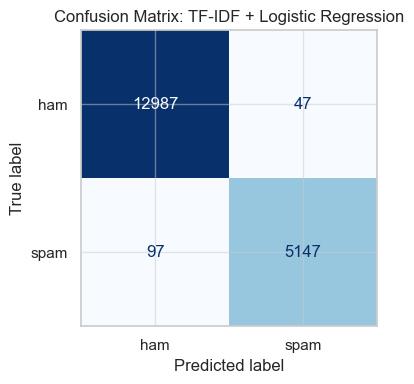

In [21]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix: TF-IDF + Logistic Regression")

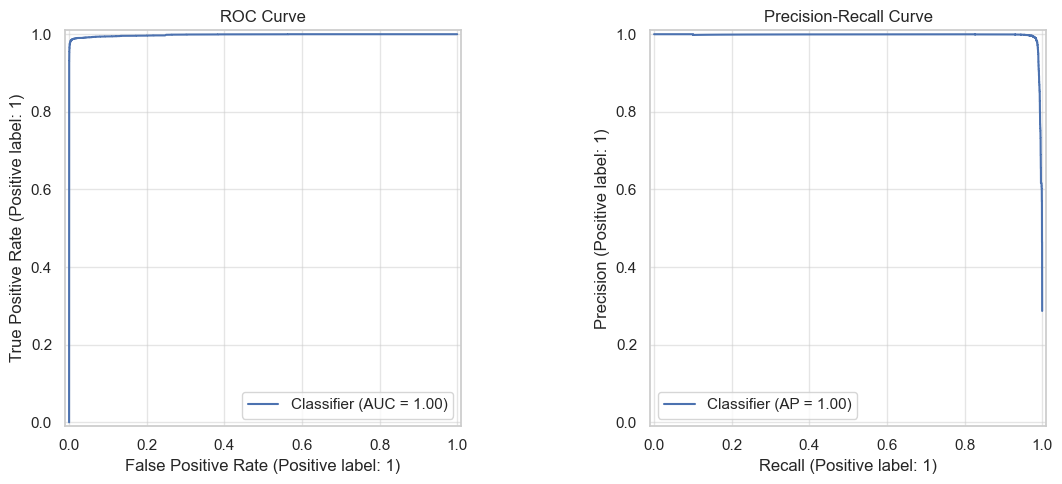

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

## 11. CV-стабільність найкращої моделі

In [23]:
cv_scores = cross_val_score(
    clone(best_model),
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

print("5-fold CV F1 scores:", np.round(cv_scores, 4))
print("Mean F1:", round(cv_scores.mean(), 4))
print("Std F1:", round(cv_scores.std(), 4))

5-fold CV F1 scores: [0.9854 0.9872 0.9864 0.9886 0.9873]
Mean F1: 0.987
Std F1: 0.0011


## 12. Аналіз найважливіших ознак

Оскільки використовується лінійна модель, можна подивитися:
- які слова/біграми найбільше “штовхають” модель у бік спаму;
- які слова/біграми характерні для не-спаму.

In [41]:
tfidf = best_model.named_steps["tfidf"]
clf = best_model.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_[0]

top_n = 20

top_spam_idx = np.argsort(coefs)[-top_n:][::-1]
top_ham_idx = np.argsort(coefs)[:top_n]

top_spam_features = pd.DataFrame({
    "feature": feature_names[top_spam_idx],
    "weight": coefs[top_spam_idx],
})

top_ham_features = pd.DataFrame({
    "feature": feature_names[top_ham_idx],
    "weight": coefs[top_ham_idx],
})

In [42]:
display(top_spam_features)

,feature,weight
0,__url__,20.149560
1,грн,18.633895
2,лс,12.171960
3,пишіть,11.162590
4,оплата,10.624339
5,пиши,10.288469
6,ціна,10.055649
7,бот,8.587305
8,відгуки,8.506846
9,графік,8.495727


In [43]:
display(top_ham_features)

,feature,weight
0,__link__,-5.818460
1,повітряна,-5.558244
2,єрадар,-4.305564
3,але,-4.219352
4,шо,-3.789859
5,збір,-3.568294
6,тривога,-3.546458
7,року,-3.333867
8,секай,-3.230285
9,мене,-3.190949


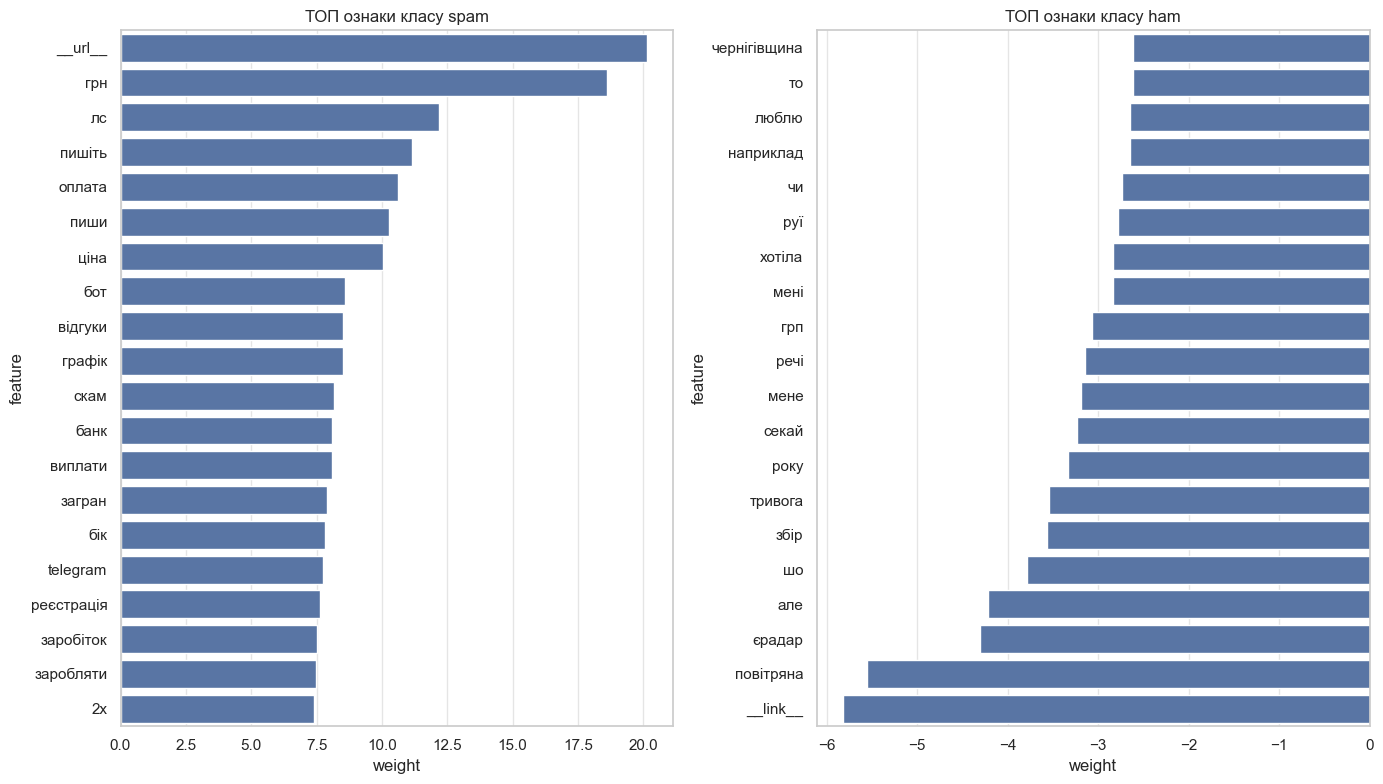

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.barplot(data=top_spam_features, x="weight", y="feature", ax=axes[0])
axes[0].set_title("ТОП ознаки класу spam")

sns.barplot(data=top_ham_features.sort_values("weight", ascending=False), x="weight", y="feature", ax=axes[1])
axes[1].set_title("ТОП ознаки класу ham")

plt.tight_layout()
plt.show()

## 13. Приклади передбачень моделі

In [44]:
examples = pd.DataFrame({
    "text": [
        "Яка сьогодні погода в Житомирі? В Чернігові дощить цілий день.",
        "Вітаю! Ви виграли приз, переходьте за посиланням",
        "Дякую за відповідь, все працює",
        "Напишіть у приватні повідомлення для деталей"
    ]
})

examples["pred_label"] = best_model.predict(examples["text"])
examples["pred_proba_spam"] = best_model.predict_proba(examples["text"])[:, 1]
display(examples)

,text,pred_label,pred_proba_spam
0,Яка сьогодні погода в Житомирі? В Чернігові до...,0,0.010408
1,"Вітаю! Ви виграли приз, переходьте за посиланням",1,0.562101
2,"Дякую за відповідь, все працює",0,0.087084
3,Напишіть у приватні повідомлення для деталей,1,0.928278


## 14. Збереження моделі

In [27]:
model_path = MODEL_DIR / "tfidf_logreg_pipeline.joblib"
joblib.dump(best_model, model_path)

print(f"Model saved to: {model_path.resolve()}")

Model saved to: C:\Users\Hyperion\PycharmProjects\SpamFilteringSystem\artifacts\tfidf_logreg_pipeline.joblib
